Импорт библиотек

In [1]:
import random
import random as random
import numpy as np
import matplotlib.pyplot as plt
import math

Основые параметры

In [2]:
shirina_polotna = 2060 # ширина полотна
shirina_polotna_min = 1980 # минимальная загурзка полотна по ширине
lp = 4 # количество лучших полотен по которым суммируеться ошибка

Заказ

In [3]:
zakaz = [[2750, 1830, 2650],
[1080, 370, 1570],
[1210, 310, 1410],
[1080, 370, 7600],
[1080, 460, 5790],
[1250, 350, 10040],
[1400, 470, 10060],
[2020, 560, 2000],
[2080, 480, 1160],
[1080, 380, 1520],
[1080, 370, 1520],
[1080, 370, 10650]]


In [4]:
print(zakaz)

[[2750, 1830, 2650], [1080, 370, 1570], [1210, 310, 1410], [1080, 370, 7600], [1080, 460, 5790], [1250, 350, 10040], [1400, 470, 10060], [2020, 560, 2000], [2080, 480, 1160], [1080, 380, 1520], [1080, 370, 1520], [1080, 370, 10650]]


## Подготовка данных

Добавляем в конец субсписка идентификатор заказа для контроля заказов

In [5]:
for ij, sublist in enumerate(zakaz):
    sublist.insert(3, ij+1)
print(zakaz)
print("Количество заказов: ", len(zakaz))

[[2750, 1830, 2650, 1], [1080, 370, 1570, 2], [1210, 310, 1410, 3], [1080, 370, 7600, 4], [1080, 460, 5790, 5], [1250, 350, 10040, 6], [1400, 470, 10060, 7], [2020, 560, 2000, 8], [2080, 480, 1160, 9], [1080, 380, 1520, 10], [1080, 370, 1520, 11], [1080, 370, 10650, 12]]
Количество заказов:  12


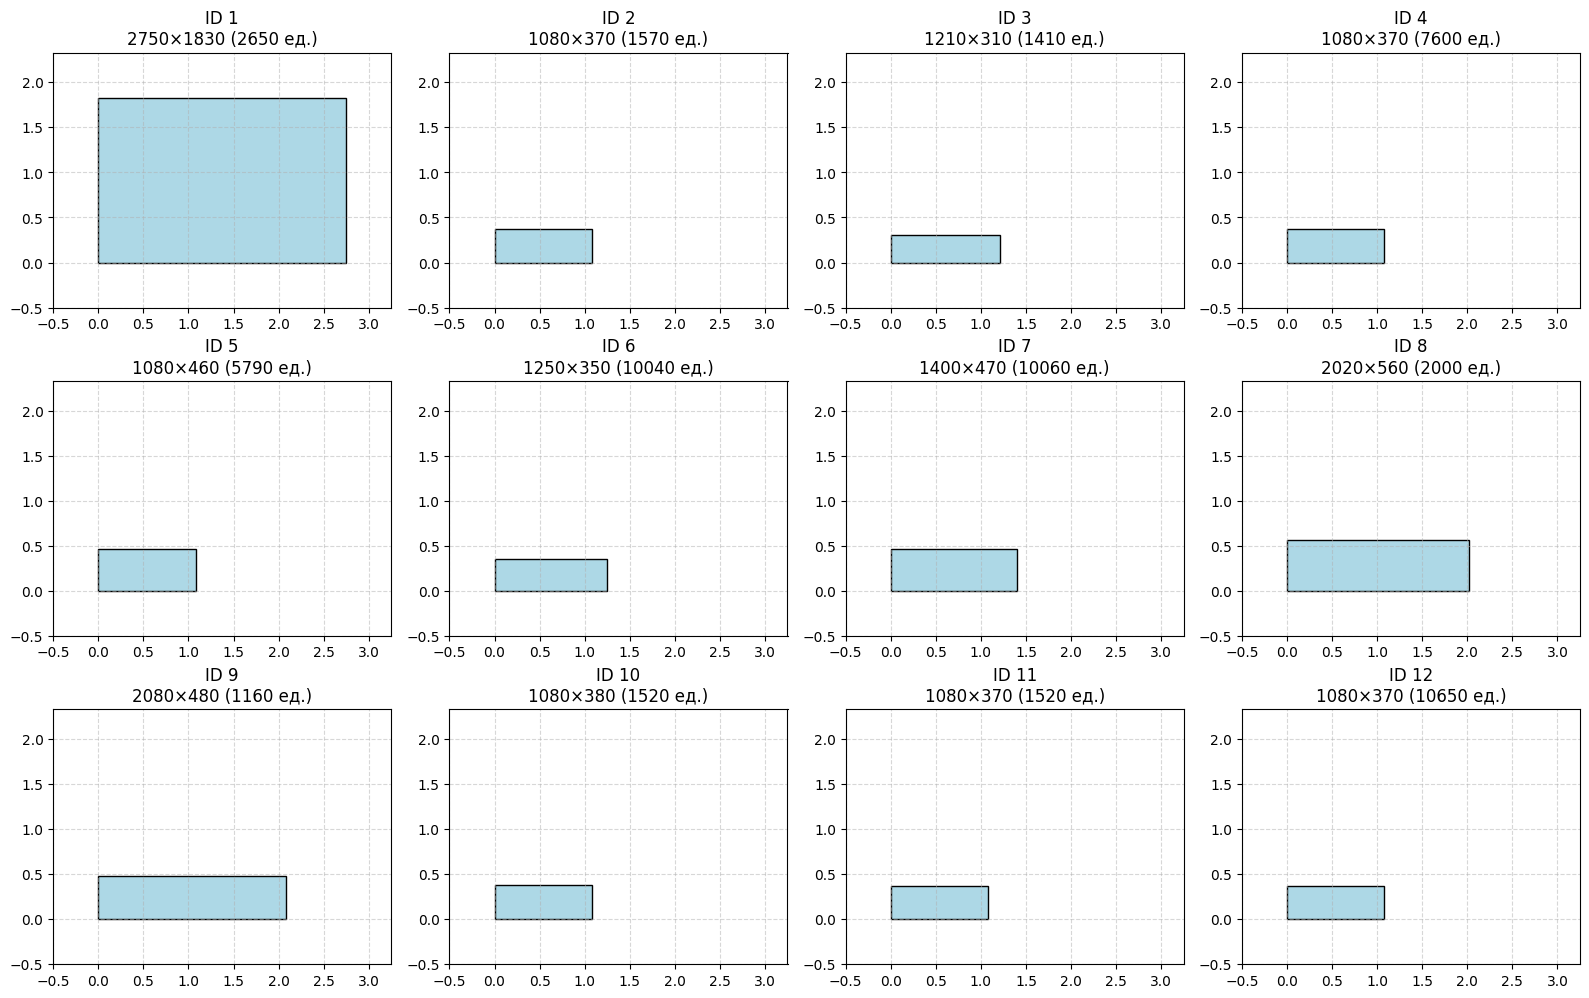

In [6]:
# @title Визуализация размеров изделий
scale = 0.001

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, (length, width, qty, zakaz_id) in enumerate(zakaz):
    ax = axes[idx]
    rect = plt.Rectangle((0, 0), length * scale, width * scale,
                         edgecolor='black', facecolor='lightblue')
    ax.add_patch(rect)
    ax.set_xlim(-0.5, max(l * scale for l, *_ in zakaz) + 0.5)
    ax.set_ylim(-0.5, max(w * scale for _, w, *_ in zakaz) + 0.5)
    ax.set_aspect('equal')
    ax.set_title(f'ID {zakaz_id}\n{length}×{width} ({qty} ед.)')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Добавление в начало списка длины полосы

In [7]:
zakaz_polosa = [[sublist[0]*sublist[2], sublist[0], sublist[1], sublist[2], sublist[3]] for sublist in zakaz]
print(zakaz_polosa)

[[7287500, 2750, 1830, 2650, 1], [1695600, 1080, 370, 1570, 2], [1706100, 1210, 310, 1410, 3], [8208000, 1080, 370, 7600, 4], [6253200, 1080, 460, 5790, 5], [12550000, 1250, 350, 10040, 6], [14084000, 1400, 470, 10060, 7], [4040000, 2020, 560, 2000, 8], [2412800, 2080, 480, 1160, 9], [1641600, 1080, 380, 1520, 10], [1641600, 1080, 370, 1520, 11], [11502000, 1080, 370, 10650, 12]]


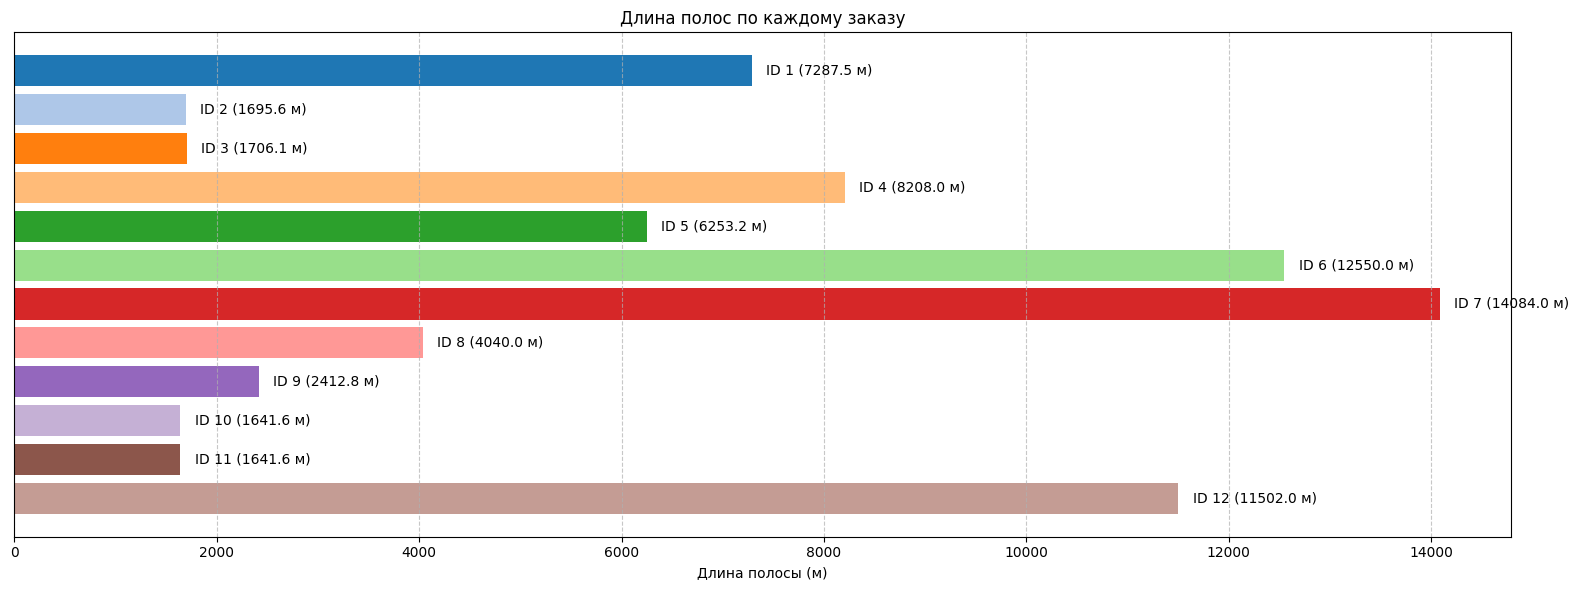

In [8]:
# @title Визаулизация длин полос
lenta_m = [row[0] / 1000 for row in zakaz_polosa]
id_zakazov = [row[4] for row in zakaz_polosa]

plt.figure(figsize=(16, 6))  # Увеличил ширину
colors = plt.cm.tab20.colors
bars = plt.barh(id_zakazov, lenta_m, color=[colors[i % len(colors)] for i in range(len(zakaz_polosa))])

for bar, order_id, total_m in zip(bars, id_zakazov, lenta_m):
    plt.text(bar.get_width() + max(lenta_m) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'ID {order_id} ({total_m:.1f} м)',
             va='center', ha='left', fontsize=10)

plt.xlabel('Длина полосы (м)')
plt.ylabel('')
plt.yticks([])
plt.title('Длина полос по каждому заказу')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.subplots_adjust(right=0.88)  # Ещё больше места справа
plt.tight_layout()
plt.show()

Определяем минимальную длину среди заказов (полос)

In [9]:
min_val = min([sub_lst[0] for sub_lst in zakaz_polosa])
min_val

1641600

Дробление

In [10]:
# @title
droblenie = []

for sub_lst in zakaz_polosa:  # перебираем каждый список в списке
    # Распаковываем данные
    total_length = sub_lst[0]  # общая длина полосы
    d = sub_lst[1]             # длина изделия
    h = sub_lst[2]             # ширина
    cnt = sub_lst[3]           # количество штук
    orig_id = sub_lst[4]       # номер изделия

    # 1. Определяем МИНИМАЛЬНОЕ количество частей
    # Используем round
    fgg = total_length / min_val
    parts = int(round(fgg))  # количество частей
    parts = max(1, parts)    # хотя бы 1 часть
    parts = min(parts, cnt)  # не больше чем изделий

    # 2. Распределяем количество изделий на целые части
    # Теперь распределяем так, чтобы сумма осталась cnt
    base = cnt // parts      # базовое количество в каждой части
    rem = cnt % parts        # остаток (сколько частей получат +1)

    # Формируем массив количеств для каждой части
    parts_counts = [base + 1] * rem + [base] * (parts - rem)

    # 3. Создаем части с целыми количествами
    for p_idx, cnt_part in enumerate(parts_counts):
        if cnt_part <= 0:  # пропускаем пустые части
            continue

        # Длина этой части (целое количество изделий × длина одного)
        part_length = cnt_part * d

        # Идентификатор части
        new_id = orig_id + (p_idx / 10.0)

        # Добавляем в результат
        droblenie.append([part_length, d, h, cnt_part, new_id])

droblenie

[[1823250, 2750, 1830, 663, 1.0],
 [1823250, 2750, 1830, 663, 1.1],
 [1820500, 2750, 1830, 662, 1.2],
 [1820500, 2750, 1830, 662, 1.3],
 [1695600, 1080, 370, 1570, 2.0],
 [1706100, 1210, 310, 1410, 3.0],
 [1641600, 1080, 370, 1520, 4.0],
 [1641600, 1080, 370, 1520, 4.1],
 [1641600, 1080, 370, 1520, 4.2],
 [1641600, 1080, 370, 1520, 4.3],
 [1641600, 1080, 370, 1520, 4.4],
 [1563840, 1080, 460, 1448, 5.0],
 [1563840, 1080, 460, 1448, 5.1],
 [1562760, 1080, 460, 1447, 5.2],
 [1562760, 1080, 460, 1447, 5.3],
 [1568750, 1250, 350, 1255, 6.0],
 [1568750, 1250, 350, 1255, 6.1],
 [1568750, 1250, 350, 1255, 6.2],
 [1568750, 1250, 350, 1255, 6.3],
 [1568750, 1250, 350, 1255, 6.4],
 [1568750, 1250, 350, 1255, 6.5],
 [1568750, 1250, 350, 1255, 6.6],
 [1568750, 1250, 350, 1255, 6.7],
 [1565200, 1400, 470, 1118, 7.0],
 [1565200, 1400, 470, 1118, 7.1],
 [1565200, 1400, 470, 1118, 7.2],
 [1565200, 1400, 470, 1118, 7.3],
 [1565200, 1400, 470, 1118, 7.4],
 [1565200, 1400, 470, 1118, 7.5],
 [1565200, 140

Количество полос после дробеления

In [11]:
len(droblenie)

44

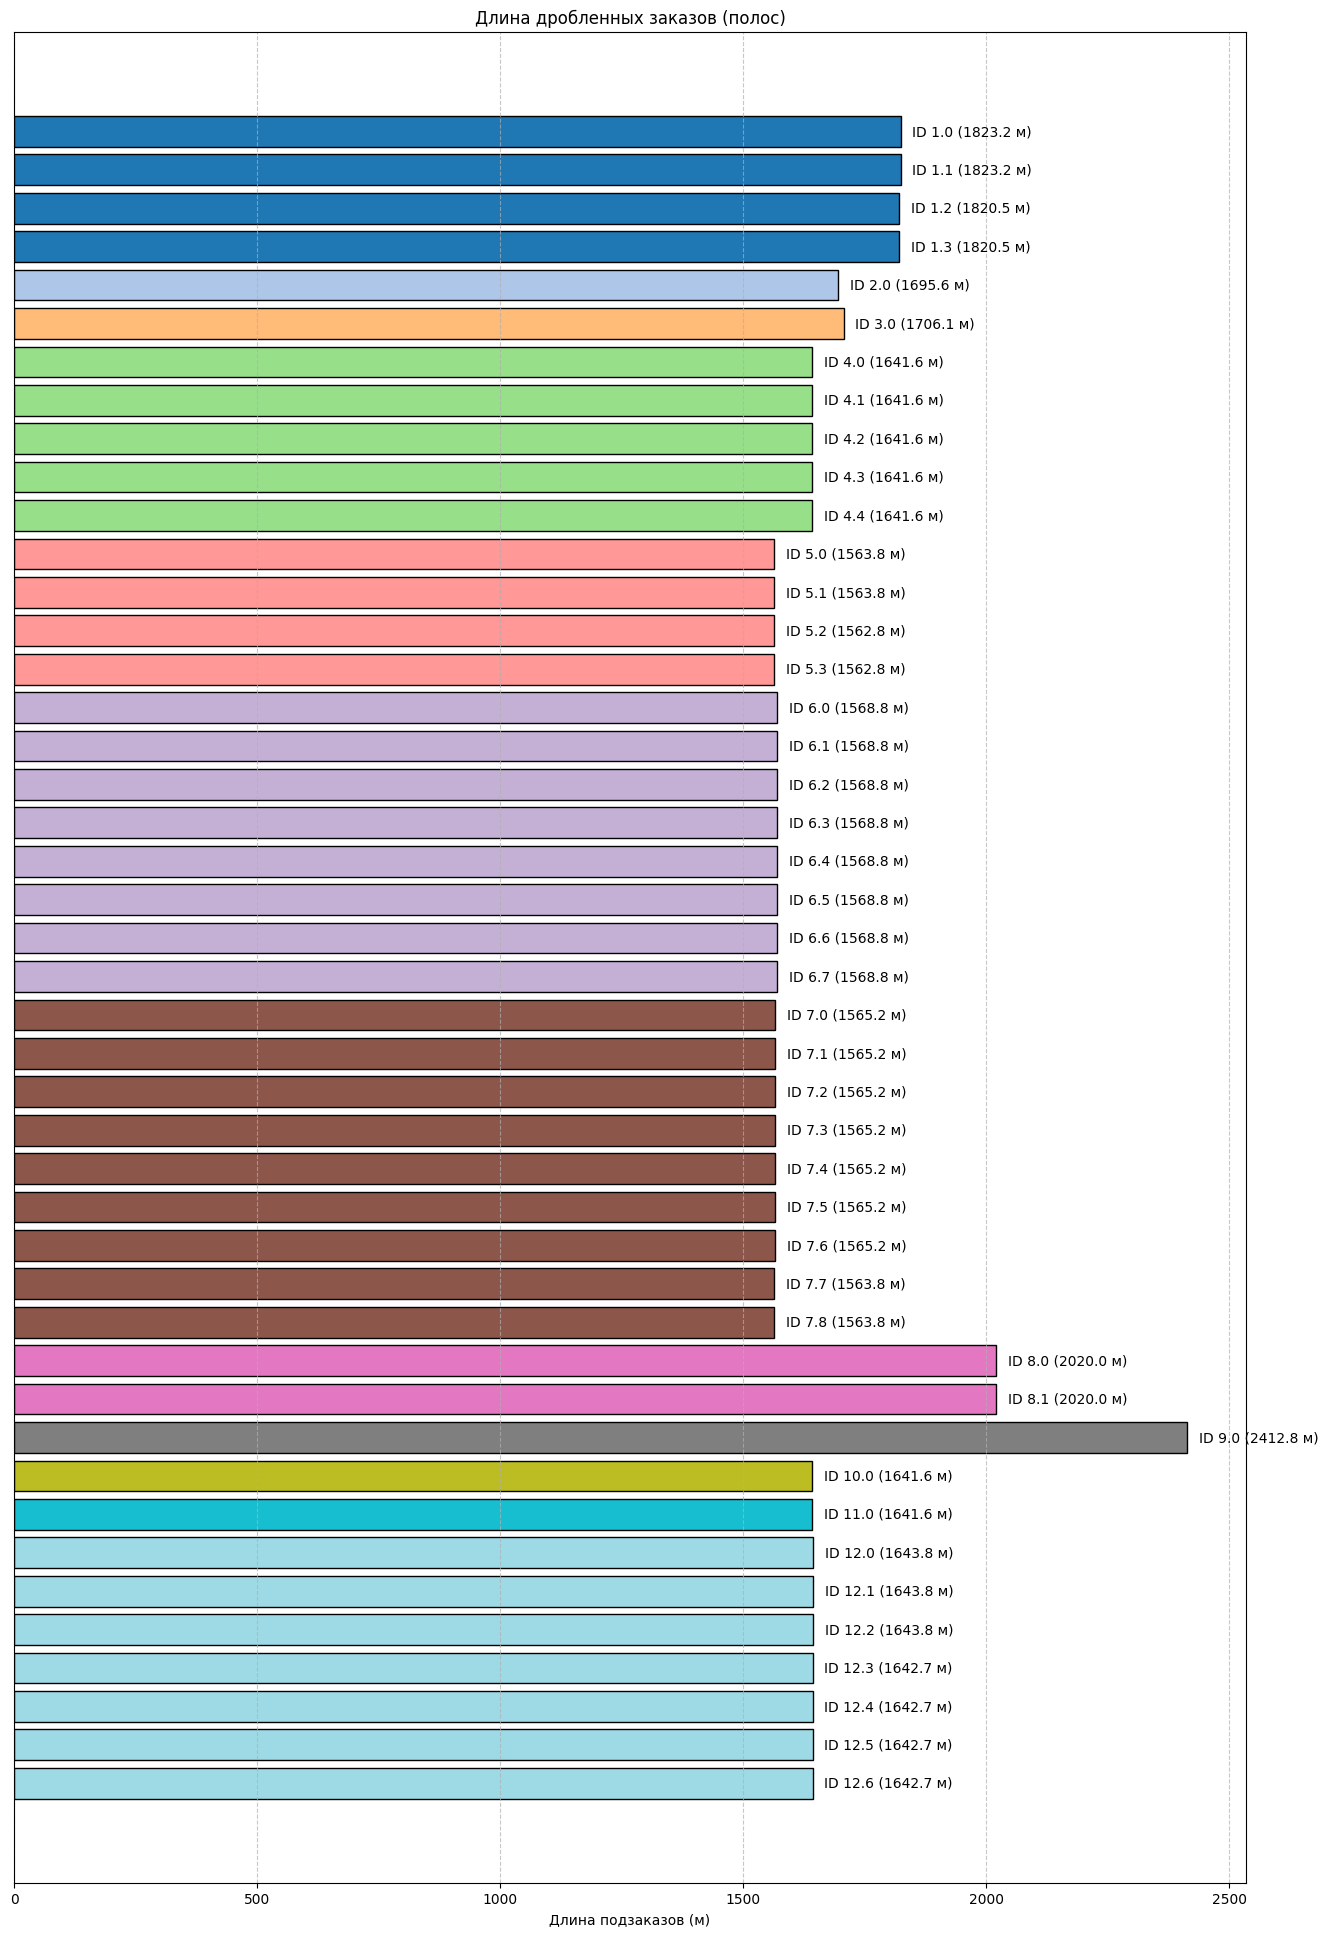

In [12]:
# @title Визуализация дробленных заказов

total_lengths_m = [order[0] / 1000 for order in droblenie]
suborder_ids = [order[4] for order in droblenie]
base_ids = [int(pid) for pid in suborder_ids]


unique_base_ids = sorted(set(base_ids))
color_map = plt.cm.tab20(np.linspace(0, 1, len(unique_base_ids)))
colors = [color_map[unique_base_ids.index(bid)] for bid in base_ids]


plt.figure(figsize=(14, 20))
positions = np.arange(len(droblenie))
bars = plt.barh(positions, total_lengths_m, color=colors, edgecolor='black')


for i, (bar, sub_id, length_m) in enumerate(zip(bars, suborder_ids, total_lengths_m)):
    plt.text(bar.get_width() + max(total_lengths_m) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'ID {sub_id} ({length_m:.1f} м)',
             va='center', ha='left', fontsize=10)

plt.xlabel('Длина подзаказов (м)')
plt.ylabel('')
plt.yticks([])
plt.title('Длина дробленных заказов (полос)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.subplots_adjust(right=0.85)
plt.tight_layout(pad=3.0)
plt.show()

Заказ дробленный

In [13]:
polosa = [[sublist[1], sublist[2], sublist[3], sublist[4]] for sublist in droblenie]
print(polosa)
print(len(polosa))

[[2750, 1830, 663, 1.0], [2750, 1830, 663, 1.1], [2750, 1830, 662, 1.2], [2750, 1830, 662, 1.3], [1080, 370, 1570, 2.0], [1210, 310, 1410, 3.0], [1080, 370, 1520, 4.0], [1080, 370, 1520, 4.1], [1080, 370, 1520, 4.2], [1080, 370, 1520, 4.3], [1080, 370, 1520, 4.4], [1080, 460, 1448, 5.0], [1080, 460, 1448, 5.1], [1080, 460, 1447, 5.2], [1080, 460, 1447, 5.3], [1250, 350, 1255, 6.0], [1250, 350, 1255, 6.1], [1250, 350, 1255, 6.2], [1250, 350, 1255, 6.3], [1250, 350, 1255, 6.4], [1250, 350, 1255, 6.5], [1250, 350, 1255, 6.6], [1250, 350, 1255, 6.7], [1400, 470, 1118, 7.0], [1400, 470, 1118, 7.1], [1400, 470, 1118, 7.2], [1400, 470, 1118, 7.3], [1400, 470, 1118, 7.4], [1400, 470, 1118, 7.5], [1400, 470, 1118, 7.6], [1400, 470, 1117, 7.7], [1400, 470, 1117, 7.8], [2020, 560, 1000, 8.0], [2020, 560, 1000, 8.1], [2080, 480, 1160, 9.0], [1080, 380, 1520, 10.0], [1080, 370, 1520, 11.0], [1080, 370, 1522, 12.0], [1080, 370, 1522, 12.1], [1080, 370, 1522, 12.2], [1080, 370, 1521, 12.3], [1080, 37

Общая ширина всех полос

In [14]:
sums = [sum(zakaz_lenta[1] for zakaz_lenta in polosa)][0]
sums

23660

Количество полотен необходимых для всех заказов

In [15]:
kol_poloten = math.ceil(sums / shirina_polotna)  #общую ширину всех полос / ширину полотна
kol_poloten

12

**В генетический алгоримт пойдут:**

In [16]:
polosa # Основной список

[[2750, 1830, 663, 1.0],
 [2750, 1830, 663, 1.1],
 [2750, 1830, 662, 1.2],
 [2750, 1830, 662, 1.3],
 [1080, 370, 1570, 2.0],
 [1210, 310, 1410, 3.0],
 [1080, 370, 1520, 4.0],
 [1080, 370, 1520, 4.1],
 [1080, 370, 1520, 4.2],
 [1080, 370, 1520, 4.3],
 [1080, 370, 1520, 4.4],
 [1080, 460, 1448, 5.0],
 [1080, 460, 1448, 5.1],
 [1080, 460, 1447, 5.2],
 [1080, 460, 1447, 5.3],
 [1250, 350, 1255, 6.0],
 [1250, 350, 1255, 6.1],
 [1250, 350, 1255, 6.2],
 [1250, 350, 1255, 6.3],
 [1250, 350, 1255, 6.4],
 [1250, 350, 1255, 6.5],
 [1250, 350, 1255, 6.6],
 [1250, 350, 1255, 6.7],
 [1400, 470, 1118, 7.0],
 [1400, 470, 1118, 7.1],
 [1400, 470, 1118, 7.2],
 [1400, 470, 1118, 7.3],
 [1400, 470, 1118, 7.4],
 [1400, 470, 1118, 7.5],
 [1400, 470, 1118, 7.6],
 [1400, 470, 1117, 7.7],
 [1400, 470, 1117, 7.8],
 [2020, 560, 1000, 8.0],
 [2020, 560, 1000, 8.1],
 [2080, 480, 1160, 9.0],
 [1080, 380, 1520, 10.0],
 [1080, 370, 1520, 11.0],
 [1080, 370, 1522, 12.0],
 [1080, 370, 1522, 12.1],
 [1080, 370, 1522, 12

In [17]:
kol_poloten # количество полотен

12

In [18]:
lp # число лучших полотен

4

In [19]:
shirina_polotna # ширина полотна

2060

In [20]:
shirina_polotna_min # минимальная загрузка полотна

1980

##Функции

In [21]:
# @title Функция отбора элиты
def getSurvPopul(
        popul, # исходный список ботов
        val,   # несортированный список значений (f) для каждого бота
        nsurv, # сколько лучших ботов берем для следующей популяции
        reverse # булево: True — сортировать по убыванию (максимизация), False — по возрастанию (минимизация)
        ):
    """
    Надёжная версия отбора выживших.
    Вместо поиска индекса через val.index() мы сортируем пары (index, value),
    что корректно работает при дублирующихся значениях fitness.
    Возвращает: (newpopul, sval) — новую популяцию и отсортированный список значений.
    """
    # Защита от некорректных nsurv
    nsurv = max(0, int(nsurv))
    if nsurv == 0:
        return [], sorted(val, reverse=reverse)

    # Создаём пары (index, value)
    indexed = list(enumerate(val))  # [(0, val0), (1, val1), ...]

    # Сортируем по значению, при равных значениях вторичным ключом используем индекс
    # Это даёт детерминированный и корректный выбор при дубликатах
    if reverse:
        # сортировка по убыванию значения, при равенстве — по возрастанию индекса
        indexed_sorted = sorted(indexed, key=lambda x: (-x[1], x[0]))
    else:
        # сортировка по возрастанию значения, при равенстве — по возрастанию индекса
        indexed_sorted = sorted(indexed, key=lambda x: (x[1], x[0]))

    # Собираем список отсортированных значений (как раньше)
    sval = [pair[1] for pair in indexed_sorted]

    # Берём nsurv лучших по отсортированному списку, извлекая исходные индексы
    ns = min(nsurv, len(indexed_sorted))
    newpopul = []
    for i in range(ns):
        orig_index = indexed_sorted[i][0]
        newpopul.append(popul[orig_index])

    return newpopul, sval


In [22]:
# @title Функция получения родителей
def getParents(
        curr_popul,
        nsurv
        ):

    '''
    Функция получения родителей
        Входные параметры:
        - curr_popul - текущая популяция
        - nsurv - количество выживших
    '''

    # Получаем дважды случайный индекс родителей в диапазоне от 0 до nsurv - 1
    indexp1 = random.randint(0, nsurv - 1)
    indexp2 = random.randint(0, nsurv - 1)


    # Получаем первого бота-родителя по indexp1
    botp1 = curr_popul[indexp1]

    # Получаем второго бота-родителя по indexp2
    botp2 = curr_popul[indexp2]

    # Возвращаем обоих полученных ботов
    return botp1, botp2

In [23]:
# @title Функци скрещивания
def crossPointFrom2Parents(
        botp1,
        botp2,
        idx # индекс гена
        ):

     # Получаем случайное число в диапазоне от 0 до 1
    pindex = random.random()

    # Если pindex меньше 0.5, то берем ген первого бота, иначе от второго
    if pindex < 0.5:

        x = botp1[idx]
    else:

        x = botp2[idx]

    return x

In [24]:
# @title Функция оценки (ошибки)
def function_error(bot): #функция ошибки

        error_polotna = 0

        dlina_bota = len(bot)

        polotno = [[] for _ in range(kol_pol)]
        for z in range(dlina_bota):
            polotno[bot[z]].append(z)

        va = []
        for yy in range(kol_pol):

          summ_h = 0
          maxdl = []
          summ_pl = 0
          dvuhka = []

          for n_polosi in polotno[yy]:

              d_zagotovoki = polosa[n_polosi][0]
              h_polosi = polosa[n_polosi][1]
              kol_zagotovok = polosa[n_polosi][2]

              d_polosi = d_zagotovoki * kol_zagotovok

              p_polosi = d_zagotovoki * kol_zagotovok * h_polosi

              summ_pl = summ_pl + p_polosi
              summ_h = summ_h + h_polosi

              maxdl.append(d_polosi)
              dvuhka.append(d_zagotovoki)


          if len(maxdl) == 0:
              max_dl = 1000000000

          else:
              max_dl = max(maxdl)


          if shirina_polotna < summ_h or shirina_polotna_min > summ_h:
            dh = 1e16
          else:
            dh = shirina_polotna - summ_h

          aa = dh * max_dl
          bb = (max_dl * summ_h) - summ_pl


          unique_values = set(dvuhka)
          count_unique_values = len(unique_values)

          if count_unique_values > 2:
            cc = 1e16
          else:
            cc = 0

          error_polotna = aa +  bb + cc


          va.append(error_polotna)


        sort_list = sorted(va)
        min_value_f = sum(sort_list[:lp])

        min_index = 0

        new_list = [round(x/1000000) for x in va]

        return min_value_f, new_list, polosa


In [25]:
# @title Функция оценки (ошибки)
def function_error(bot):

        error_polotna = 0  # итоговая ошибка для одного полотна

        dlina_bota = len(bot)  # количество заготовок (длина решения)

        # Формируем список полотен: какие заготовки попали на какое полотно
        polotno = [[] for _ in range(kol_pol)]
        for z in range(dlina_bota):
            polotno[bot[z]].append(z)

        va = []  # список ошибок для каждого полотна
        for yy in range(kol_pol):

          summ_h = 0      # суммарная высота заготовок на полотне
          maxdl = []      # длины полос (для поиска максимальной)
          summ_pl = 0     # суммарная полезная площадь
          dvuhka = []     # список длин заготовок (для проверки разнообразия)

          # Обрабатываем все полосы, попавшие на текущее полотно
          for n_polosi in polotno[yy]:

              d_zagotovoki = polosa[n_polosi][0]   # длина заготовки
              h_polosi = polosa[n_polosi][1]       # высота заготовки
              kol_zagotovok = polosa[n_polosi][2] # количество заготовок

              d_polosi = d_zagotovoki * kol_zagotovok  # длина всей полосы
              p_polosi = d_zagotovoki * kol_zagotovok * h_polosi  # полезная площадь

              summ_pl = summ_pl + p_polosi
              summ_h = summ_h + h_polosi

              maxdl.append(d_polosi)
              dvuhka.append(d_zagotovoki)

          # Если полотно пустое — штрафуем большим значением
          if len(maxdl) == 0:
              max_dl = 1000000000
          else:
              max_dl = max(maxdl)

          # Проверка допустимости по ширине полотна
          if shirina_polotna < summ_h or shirina_polotna_min > summ_h:
            dh = 1e16  # сильный штраф за выход за пределы
          else:
            dh = shirina_polotna - summ_h  # остаток по ширине

          aa = dh * max_dl                 # штраф за недоиспользование ширины
          bb = (max_dl * summ_h) - summ_pl # потери площади (отходы)

          # Проверяем количество уникальных длин заготовок
          unique_values = set(dvuhka)
          count_unique_values = len(unique_values)

          # Если разных длин больше двух — штраф
          if count_unique_values > 2:
            cc = 1e16
          else:
            cc = 0

          # Общая ошибка для данного полотна
          error_polotna = aa + bb + cc

          va.append(error_polotna)

        # Сортируем ошибки полотен
        sort_list = sorted(va)

        # Берём сумму ошибок лучших lp полотен
        min_value_f = sum(sort_list[:lp])

        min_index = 0  # не используется (остаток старой логики)

        # Упрощённый список ошибок (для анализа / вывода)
        new_list = [round(x/1000000) for x in va]

        return min_value_f, new_list, polosa


genes  [5, 1, 10, 6, 10, 7, 11, 8, 4, 9, 8, 2, 2, 1, 9, 10, 10, 9, 10, 4, 2, 8, 0, 4, 4, 9, 4, 2, 0, 4, 5, 11, 9, 2, 1, 3, 2, 5, 6, 1, 7, 2, 1, 6]
genes  [5, 0, 5, 0, 1, 11, 0, 10, 9, 2, 6, 3, 4, 1, 4, 7, 11, 7, 0, 1, 8, 10, 1, 0, 6, 6, 8, 1, 7, 5, 5, 4, 0, 10, 8, 2, 1, 5, 1, 10, 1, 2, 2, 4]
genes  [9, 2, 6, 6, 10, 5, 11, 2, 3, 3, 11, 5, 4, 4, 10, 5, 6, 9, 3, 6, 2, 0, 11, 10, 2, 3, 5, 5, 10, 11, 7, 8, 7, 1, 5, 3, 9, 4, 5, 6, 3, 0, 4, 2]
genes  [0, 11, 10, 5, 7, 4, 3, 0, 2, 4, 9, 5, 7, 6, 0, 1, 11, 3, 3, 7, 6, 6, 8, 0, 5, 2, 9, 2, 6, 10, 3, 11, 5, 8, 10, 11, 6, 3, 7, 11, 0, 7, 8, 5]
genes  [2, 4, 0, 1, 4, 3, 11, 2, 2, 9, 5, 9, 4, 6, 4, 3, 4, 9, 1, 9, 4, 9, 4, 0, 4, 7, 8, 0, 11, 1, 5, 6, 8, 9, 2, 10, 5, 2, 8, 8, 1, 3, 2, 9]
genes  [2, 8, 4, 10, 4, 9, 8, 6, 11, 0, 2, 1, 2, 7, 11, 11, 7, 2, 2, 7, 10, 5, 6, 6, 8, 9, 10, 4, 11, 9, 2, 7, 7, 2, 5, 4, 6, 8, 6, 2, 5, 8, 4, 2]
genes  [5, 0, 5, 4, 9, 6, 2, 3, 9, 5, 4, 5, 4, 4, 3, 11, 2, 0, 4, 0, 1, 11, 4, 1, 3, 11, 7, 1, 8, 8, 4, 10, 0, 6, 2, 2, 0

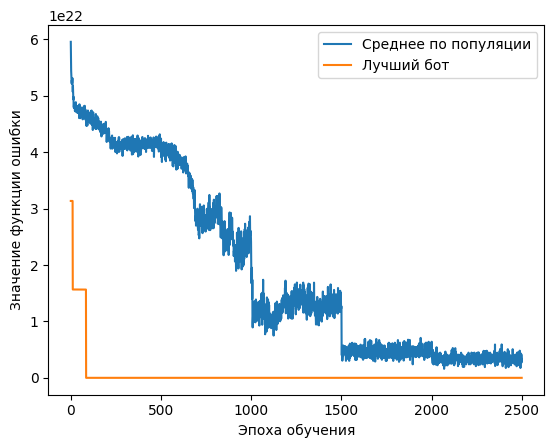

In [26]:
# @title Полный цикл генетического поиска

# -----------------------------
# Основные параметры алгоритма
# -----------------------------

n = 100          # Общее количество ботов в популяции (размер популяции)
nsurv = 40       # Сколько лучших ботов выживает и переходит в следующую эпоху
nnew = n-nsurv   # Сколько новых ботов будет создано заново
epohs = 2500     # Количество эпох (итераций обучения)

mut = 0.5        # Вероятность мутации гена
# Эпохи, на которых уменьшаем вероятность мутации
eph_change_mut = [500, 1000, 1500, 2000]
# Новые значения вероятности мутации
new_mut = [0.1, 0.05, 0.01, 0.005]

# Длина бота — количество полос (один ген = одно решение,
# на какое полотно положить полосу)
l = len(polosa)

# --------------------------------
# Инициализация популяции
# --------------------------------

popul = []   # Список всех ботов (каждый бот — список генов)
val = []     # Значения функции ошибки для каждого бота

# Списки для построения графиков
plotmeanval = []  # Среднее значение ошибки по популяции
plotminval = []   # Минимальная ошибка (лучший бот)

# --------------------------------
# Создание начальной популяции
# --------------------------------
for i in range(n):

    genes = []  # Будущий бот

    # Для каждого гена выбираем случайное полотно,
    # на которое будет положена соответствующая полоса
    for iii in range(l):
        gen = random.randint(0, kol_poloten - 1)
        genes.append(gen)

    print("genes ", genes)
    popul.append(genes)

# --------------------------------
# Основной цикл генетического алгоритма
# --------------------------------
for it in range(epohs):

    # Проверяем, нужно ли изменить вероятность мутации
    if it in eph_change_mut:
        idx = eph_change_mut.index(it)
        mut = new_mut[idx]

    val = []              # Очищаем список ошибок
    kol_pol = kol_poloten  # Количество полотен

    # --------------------------------
    # Оценка всех ботов текущей популяции
    # --------------------------------
    for y in range(n):

        bot = popul[y]  # Берём очередного бота

        # Считаем ошибку раскроя для этого бота
        min_value_f, nomer_polotna, polosa = function_error(bot)

        val.append(min_value_f)

    # --------------------------------
    # Отбор лучших ботов
    # --------------------------------

    # Получаем:
    # - новую популяцию из лучших ботов
    # - отсортированный список значений ошибки
    newpopul, sval = getSurvPopul(popul, val, nsurv, 0)

    # Сохраняем статистику для графиков
    plotmeanval.append(sum(val) / len(val))  # среднее по популяции
    plotminval.append(sval[0])               # лучший результат эпохи

    # --------------------------------
    # Создание новых ботов (скрещивание + мутация)
    # --------------------------------
    for s in range(nnew):

        # Выбираем двух родителей из выживших
        botp1, botp2 = getParents(newpopul, nsurv)

        newbot = []  # Новый бот

        # Формируем нового бота по генам
        for j in range(l):

            # Берём ген от одного из родителей
            x = crossPointFrom2Parents(botp1, botp2, j)

            # С вероятностью mut происходит мутация —
            # ген заменяется случайным значением
            if random.random() < mut:
                x = random.randint(0, kol_poloten - 1)

            newbot.append(x)

        # Добавляем нового бота в популяцию
        newpopul.append(newbot)

    # Обновляем популяцию
    popul = newpopul

# --------------------------------
# Построение графиков обучения
# --------------------------------

plt.plot(plotmeanval, label='Среднее по популяции')
plt.plot(plotminval, label='Лучший бот')
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение функции ошибки')
plt.legend()
plt.show()


#Итоги

In [27]:
# Выводим 3 лучших ботов
for i in range(3):
    print(popul[i])

[6, 3, 2, 0, 10, 2, 8, 0, 1, 7, 8, 11, 6, 10, 9, 3, 2, 4, 11, 4, 11, 11, 0, 5, 5, 8, 7, 1, 1, 8, 0, 7, 11, 4, 3, 7, 7, 5, 5, 5, 1, 8, 1, 0]
[9, 3, 2, 0, 10, 6, 8, 3, 1, 7, 8, 3, 6, 10, 9, 3, 2, 4, 11, 10, 0, 11, 0, 5, 5, 8, 7, 1, 1, 8, 10, 7, 11, 4, 3, 7, 7, 5, 5, 5, 1, 8, 1, 0]
[6, 3, 2, 0, 10, 2, 8, 0, 1, 7, 8, 11, 6, 10, 9, 3, 2, 4, 10, 4, 0, 3, 3, 5, 5, 8, 7, 1, 1, 8, 0, 7, 11, 4, 3, 7, 7, 5, 5, 5, 1, 8, 1, 0]


Берем лучшего бота и для него рассшифровываем результаы

In [28]:
best_bot = popul[0]
print("Лучший бот: ", best_bot)

dlina_botika = len(best_bot)

min_value_f, nomer_polotna, polosa = function_error(best_bot)

nom_l_plus1 = 1000000000

polotno2 = [[] for _ in range(kol_pol)]
for i in range(dlina_botika):
      polotno2[best_bot[i]].append(i)  # добавляем индекс (изделия) в список равный значению гена


# создаем список списков из id полос на полотнах
polotno3 = [[] for _ in range(kol_pol)]
for iw in range(dlina_botika):
      if iw == nom_l_plus1:
          polotno3[best_bot[iw]].append(1000)
      else:
          polotno3[best_bot[iw]].append(polosa[iw][3])  # добавляем индекс (изделия) в список равный значению гена


print("Распределение id заказов по полотнам:", polotno3)
print("Расределение ошибок по полотнам:", nomer_polotna)


Лучший бот:  [6, 3, 2, 0, 10, 2, 8, 0, 1, 7, 8, 11, 6, 10, 9, 3, 2, 4, 11, 4, 11, 11, 0, 5, 5, 8, 7, 1, 1, 8, 0, 7, 11, 4, 3, 7, 7, 5, 5, 5, 1, 8, 1, 0]
Распределение id заказов по полотнам: [[1.3, 4.1, 6.7, 7.7, 12.6], [4.2, 7.4, 7.5, 12.3, 12.5], [1.2, 3.0, 6.1], [1.1, 6.0, 9.0], [6.2, 6.4, 8.1], [7.0, 7.1, 12.0, 12.1, 12.2], [1.0, 5.1], [4.3, 7.3, 7.8, 10.0, 11.0], [4.0, 4.4, 7.2, 7.6, 12.4], [5.3], [2.0, 5.2], [5.0, 6.3, 6.5, 6.6, 8.0]]
Расределение ошибок по полотнам: [18205010000000340, 90, 18205010000000124, 24128010000001376, 20200000000000312, 90, 18232500000000120, 72, 90, 15627600000000000, 16956000000000062, 20200010000000680]


Ранжированный список ошибок (72, 90, 90, 90, 15627600000000000, 16956000000000062, 18205010000000124, 18205010000000340, 18232500000000120, 20200000000000312, 20200010000000680, 24128010000001376)
Индексы полотен  (7, 1, 5, 8, 9, 10, 2, 0, 6, 4, 11, 3)



Индекс полотна:  7
id подзаказов:  [4.3, 7.3, 7.8, 10.0, 11.0]
[[1641600, 370], [1565200, 470], [1563800, 470], [1641600, 380], [1641600, 370]] [длина (мм), ширина (мм)]
Список длин изделий: [1080, 1400, 1400, 1080, 1080]
Общая ширина полос: 2060 мм
Обрезь: 72.474 м2
Ошибка: 72 м2


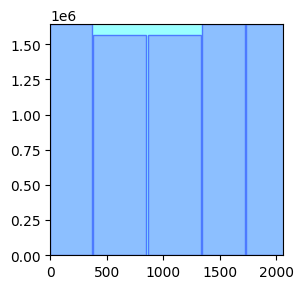



Индекс полотна:  1
id подзаказов:  [4.2, 7.4, 7.5, 12.3, 12.5]
[[1641600, 370], [1565200, 470], [1565200, 470], [1642680, 370], [1642680, 370]] [длина (мм), ширина (мм)]
Список длин изделий: [1080, 1400, 1400, 1080, 1080]
Общая ширина полос: 2050 мм
Обрезь: 89.6576 м2
Ошибка: 90 м2


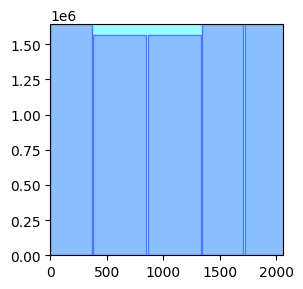



Индекс полотна:  5
id подзаказов:  [7.0, 7.1, 12.0, 12.1, 12.2]
[[1565200, 470], [1565200, 470], [1643760, 370], [1643760, 370], [1643760, 370]] [длина (мм), ширина (мм)]
Список длин изделий: [1400, 1400, 1080, 1080, 1080]
Общая ширина полос: 2050 мм
Обрезь: 90.284 м2
Ошибка: 90 м2


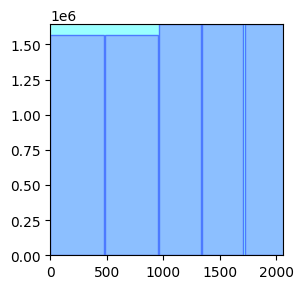



Индекс полотна:  8
id подзаказов:  [4.0, 4.4, 7.2, 7.6, 12.4]
[[1641600, 370], [1641600, 370], [1565200, 470], [1565200, 470], [1642680, 370]] [длина (мм), ширина (мм)]
Список длин изделий: [1080, 1080, 1400, 1400, 1080]
Общая ширина полос: 2050 мм
Обрезь: 90.0572 м2
Ошибка: 90 м2


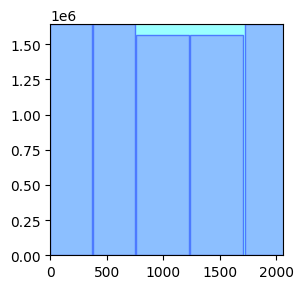



Индекс полотна:  9
id подзаказов:  [5.3]
[[1562760, 460]] [длина (мм), ширина (мм)]
Список длин изделий: [1080]
Общая ширина полос: 460 мм
Обрезь: 2500.416 м2
Ошибка: 15627600000000000 м2


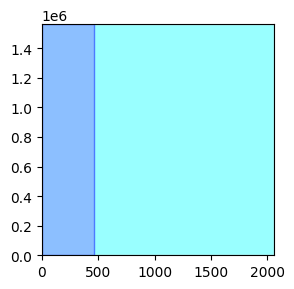



Индекс полотна:  10
id подзаказов:  [2.0, 5.2]
[[1695600, 370], [1562760, 460]] [длина (мм), ширина (мм)]
Список длин изделий: [1080, 1080]
Общая ширина полос: 830 мм
Обрезь: 2146.6944 м2
Ошибка: 16956000000000062 м2


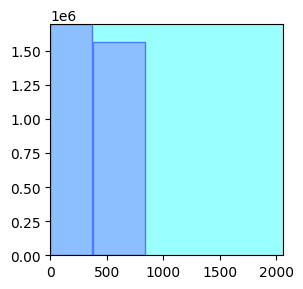



Индекс полотна:  2
id подзаказов:  [1.2, 3.0, 6.1]
[[1820500, 1830], [1706100, 310], [1568750, 350]] [длина (мм), ширина (мм)]
Список длин изделий: [2750, 1210, 1250]
Общая ширина полос: 2490 мм
Обрезь: -659.2385 м2
Ошибка: 18205010000000124 м2


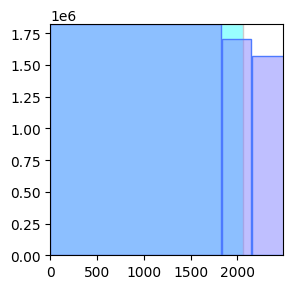



Индекс полотна:  0
id подзаказов:  [1.3, 4.1, 6.7, 7.7, 12.6]
[[1820500, 1830], [1641600, 370], [1568750, 350], [1563800, 470], [1642680, 370]] [длина (мм), ширина (мм)]
Список длин изделий: [2750, 1080, 1250, 1400, 1080]
Общая ширина полос: 3390 мм
Обрезь: -2080.5171 м2
Ошибка: 18205010000000340 м2


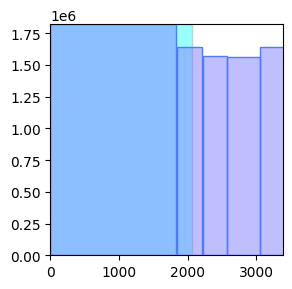



Индекс полотна:  6
id подзаказов:  [1.0, 5.1]
[[1823250, 1830], [1563840, 460]] [длина (мм), ширина (мм)]
Список длин изделий: [2750, 1080]
Общая ширина полос: 2290 мм
Обрезь: -300.0189 м2
Ошибка: 18232500000000120 м2


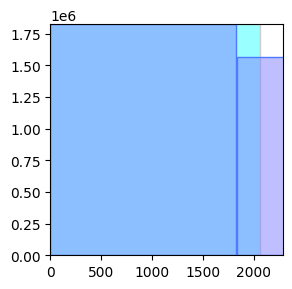



Индекс полотна:  4
id подзаказов:  [6.2, 6.4, 8.1]
[[1568750, 350], [1568750, 350], [2020000, 560]] [длина (мм), ширина (мм)]
Список длин изделий: [1250, 1250, 2020]
Общая ширина полос: 1260 мм
Обрезь: 1931.875 м2
Ошибка: 20200000000000312 м2


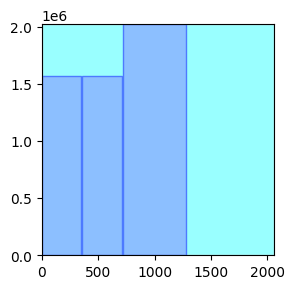



Индекс полотна:  11
id подзаказов:  [5.0, 6.3, 6.5, 6.6, 8.0]
[[1563840, 460], [1568750, 350], [1568750, 350], [1568750, 350], [2020000, 560]] [длина (мм), ширина (мм)]
Список длин изделий: [1080, 1250, 1250, 1250, 2020]
Общая ширина полос: 2070 мм
Обрезь: 663.4461 м2
Ошибка: 20200010000000680 м2


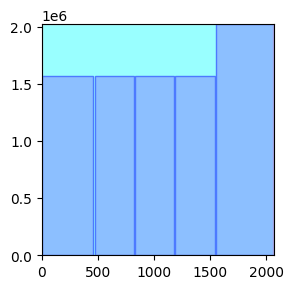



Индекс полотна:  3
id подзаказов:  [1.1, 6.0, 9.0]
[[1823250, 1830], [1568750, 350], [2412800, 480]] [длина (мм), ширина (мм)]
Список длин изделий: [2750, 1250, 2080]
Общая ширина полос: 2660 мм
Обрезь: -73.386 м2
Ошибка: 24128010000001376 м2


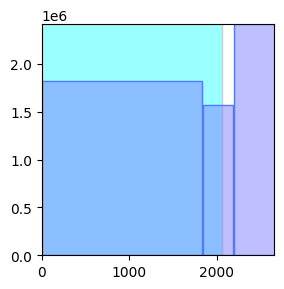

In [29]:
# @title Визуализация результатов
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fff, nom, polosa = function_error(best_bot)   # забираем список ошибок по листам

# создаем список кортежей, содержащих значения и их индексы
indexed_list = list(enumerate(nom))

    # сортируем список кортежей по значениям
sorted_list = sorted(indexed_list, key=lambda x: x[1])

    # используем метод zip() для разделения значений и индексов на два списка
nom_ind, nom_sorted  = zip(*sorted_list)
print("Ранжированный список ошибок", nom_sorted) #список ошибок по полотнам отсортированный по возрастанию
print("Индексы полотен ", nom_ind) #список индексов для списка ошибок

print()


for i in nom_ind: #перебираем полотен

    best_shirina = []
    best_polotno = []
    best_zagatovka = []
    spisok_d_h = []
    best_plohad = []
    best_dlina = []

    best_zagatovka_dlina = []

    for ii in polotno2[i]:  # список списков (здесь полосы попавшие на полотно)
        best_zagatovka.append(polosa[ii])
        best_zagatovka_dlina.append(polosa[ii][0]) # список длин заготовок

        best_dlina.append(polosa[ii][0]*polosa[ii][2]) # список длин лент
        best_shirina.append(polosa[ii][1]) # списко ширин лент
        best_plohad.append(polosa[ii][0] * polosa[ii][1] * polosa[ii][2]) # список площадей лент
        spisok_d_h.append([polosa[ii][0]*polosa[ii][2], polosa[ii][1]])


    uni_values = set(best_dlina)
    count_uni_values = len(uni_values)

    sumaa_hir = sum(best_shirina)# Общая ширина полос
    sumaa_best_plohad = sum(best_plohad) # Общая площадь полос

    if len(best_dlina) == 0:
        obrez = 10000000
    else:
        obrez = (max(best_dlina) * shirina_polotna) - sumaa_best_plohad

    print()
    print()
    print("Индекс полотна: ", i)
    print("id подзаказов: ", polotno3[i])
    print(spisok_d_h, "[длина (мм), ширина (мм)]")
    print("Список длин изделий:", best_zagatovka_dlina)
    print("Общая ширина полос:", sumaa_hir, "мм")
    print("Обрезь:", obrez/1000000, "м2")
    print("Ошибка:", nom_sorted[nom_ind.index(i)], "м2")


    # Данные для построения диаграммы
    # задаем размеры прямоугольников в списке списков
    rect_sizes = [[sublist[1], sublist[0]] for sublist in spisok_d_h]

    # задаем начальные координаты
    x = 0
    y = 0
    # создаем фигуру
    fig, ax = plt.subplots(figsize=(3, 3))


    if len(best_dlina) != 0: #график рисуеться только в том случае, если список не пустой

        # создаем и добавляем прямоугольники на график с помощью цикла
        for size in rect_sizes:
            width, height = size
            rect = patches.Rectangle((x, y), width, height, linewidth=1, edgecolor='#4D7AFF', facecolor=(0.5, 0.5, 1, 0.5))
            ax.add_patch(rect)
            x += width + 10 # увеличиваем координату x на ширину прямоугольника и дополнительный отступ


        # добавляем второй квадрат
        rect2 = patches.Rectangle((0, 0), shirina_polotna, max(best_dlina), linewidth=1, edgecolor='#cccccc', facecolor='#99FFFF', zorder=0)
        ax.add_patch(rect2)
        # задаем пределы осей
        #ax.set_xlim([0, x - 10]) # вычитаем последний отступ из общей ширины

        if (shirina_polotna < sumaa_hir):
            r_oblasti = sumaa_hir
        else:
            r_oblasti = shirina_polotna

        ax.set_xlim([0, r_oblasti]) # учитываем ширину прямоугольников и дополнительные отступы
        ax.set_ylim([0, max(rect_sizes, key=lambda size: size[1])[1]])


        # отображаем график
        plt.show()


